## 패키지 불러오기 및 데이터 전처리

In [1]:
# 라이브러리 기본 참조
from hossam import load_data
from pandas import DataFrame, melt
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np
# 선형회귀를 위한 참조
import statsmodels.api as sm
from statsmodels.formula.api import ols
# 결과 검정을 위한 참조
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, probplot, shapiro, anderson
from statsmodels.stats.api import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
# VIF값을 계산하기 위한 참조
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns

In [2]:
from hossam import hs_util, hs_prep
from hossam import plot as hs_plot


In [3]:
import hossam
print(hossam.__file__)

c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\hossam\__init__.py


In [4]:
import os, hossam

print(os.listdir(os.path.dirname(hossam.__file__)))


['hs_classroom.py', 'hs_gis.py', 'hs_plot.py', 'hs_prep.py', 'hs_stats.py', 'hs_timeserise.py', 'hs_util.py', 'leekh.png', 'NotoSansKR-Regular.ttf', 'plot.py', 'prep.py', 'stats.py', 'util.py', '__init__.py', '__pycache__']


In [5]:
my_dpi = 200 # 이미지 선명도(100~300)
fpath = "./NotoSansKR-Regular.ttf" # 한글을 지원하는 폰트 파일의 경로
fm.fontManager.addfont(fpath) # 폰트의 글꼴을 시스템에 등록함
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트 이름 추출
plt.rcParams['font.family'] = fname # 그래프에 한글 폰트 적용
plt.rcParams['font.size'] = 6 # 기본 폰트 크기
plt.rcParams['axes.unicode_minus'] = False # 그래프에 마이너스 깨짐 방지

In [6]:
origin = load_data("insurance")
origin

개인의 나이·성별·BMI·흡연 여부·거주 지역 등 기본 건강·인구학적 정보를 바탕으로 의료보험 청구 비용(charges)을 예측하도록 구성된, 선형회귀와 머신러닝 실습에 널리 사용되는 대표적인 보험 비용 데이터셋 (출처: https://www.kaggle.com/datasets/mirichoi0218/insurance)

변수명    의미(설명)
--------  ---------------------------------------------------------------
age       가입자의 나이(세).
sex       성별 (male, female).
bmi       체질량 지수(Body Mass Index).
children  부양 자녀 수(보험 내 자녀 수).
smoker    흡연 여부 (yes / no).
region    미국 내 거주 지역 (northeast, northwest, southeast, southwest).
charges   의료보험 청구 비용(달러). 예측해야 하는 타깃 변수.



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### 📝미션 1. “이 데이터는 믿을 만할까?”결측·이상치·편향을 점검하고,<br>
처리 기준을 제시한다.charges가 음수이거나 극단값인지, age/bmi 등의 범위가 현실적인지 확인한다.<br>
범주형 변수(sex, smoker, region)가 몇 개의 범주로 구성되어 있고,<br>
특정 범주에 데이터가 지나치게 몰려 있지는않은지 확인한다.전처리 전·후가 어떻게 달라졌는지 한눈에 비교하는 표나 요약을 만든다.<br>
단위·해석 주의: charges는 USD입니다. 
현실적인 의료비 수준인지 평가하세요

In [7]:
n_rows, n_cols = origin.shape
print(f"총 행 수: {n_rows}")
print(f"총 열 수: {n_cols}")

total_nan = origin.isna().sum().sum()
print(f"총 NAN수:{total_nan}")
print(f"NaN값이 총 0개로 결측치 제거는 따로 필요하지 않았음.\n")

총 행 수: 1338
총 열 수: 7
총 NAN수:0
NaN값이 총 0개로 결측치 제거는 따로 필요하지 않았음.



### 범주형 변수 범주수

In [8]:
categorical_cols = ['sex', 'smoker', 'region', 'children']


In [23]:
for col in categorical_cols:
    print(f"\n[{col}] 관측치 분포")
    
    counts = origin[col].value_counts()
    ratios = origin[col].value_counts(normalize=True)
    
    summary = (
        counts
        .to_frame(name='count')
        .assign(ratio=ratios)
    )
    
    summary['ratio'] = summary['ratio'].map(lambda x: f"{x:.2%}")
    
    print(summary)




[sex] 관측치 분포
        count   ratio
sex                  
male      676  50.52%
female    662  49.48%

[smoker] 관측치 분포
        count   ratio
smoker               
no       1064  79.52%
yes       274  20.48%

[region] 관측치 분포
           count   ratio
region                  
southeast    364  27.20%
southwest    325  24.29%
northwest    325  24.29%
northeast    324  24.22%

[children] 관측치 분포
          count   ratio
children               
0           574  42.90%
1           324  24.22%
2           240  17.94%
3           157  11.73%
4            25   1.87%
5            18   1.35%


In [10]:
# 수치형 변수 이상치 및 현실성 점검
print("===데이터 기본 정보===")
print(origin.describe())
print(f"\n전체 데이터 수:{len(origin)}")


===데이터 기본 정보===
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010

전체 데이터 수:1338


In [11]:
# 전처리 전·후 비교 요약 표
import pandas as pd
before = origin.describe()

# 예시 전처리
clean = origin[
    (origin['charges'] >= 0) &
    (origin['age'] > 0) & (origin['age'] <= 100) &
    (origin['bmi'] >= 10) & (origin['bmi'] <= 60)
]

after = clean.describe()

comparison = pd.concat(
    {'Before': before, 'After': after},
    axis=1
)

comparison


Before                                                After  \
               age          bmi     children       charges          age   
count  1338.000000  1338.000000  1338.000000   1338.000000  1338.000000   
mean     39.207025    30.663397     1.094918  13270.422265    39.207025   
std      14.049960     6.098187     1.205493  12110.011237    14.049960   
min      18.000000    15.960000     0.000000   1121.873900    18.000000   
25%      27.000000    26.296250     0.000000   4740.287150    27.000000   
50%      39.000000    30.400000     1.000000   9382.033000    39.000000   
75%      51.000000    34.693750     2.000000  16639.912515    51.000000   
max      64.000000    53.130000     5.000000  63770.428010    64.000000   

                                               
               bmi     children       charges  
count  1338.000000  1338.000000   1338.000000  
mean     30.663397     1.094918  13270.422265  
std       6.098187     1.205493  12110.011237  
min      15.960000     0.000000   1121.873900  
25%      26.296250     0.000000   4740.287150  
50%      30.400000     1.000000   9382.033000  
75%      34.693750     2.000000  16639.912515  
max      53.130000     5.000000  63770.428010

### 📝미션 2. “의료비와 핵심 변수의 첫인상”charges, age, bmi, children 분포를 히스토그램/KDE로 확인하고 알 수 있는 객관적 사실을 서술한다.<br>
왜도/이상치가 회귀에 줄 수 있는 영향과 변환할 필요가 있는지 서술하시오.<br>
분포 비교는 동일 축 스케일로 제시하고, 평균/중앙값/꼬리의 차이를 문장으로 요약하세요.<br>
의료비의 long-tail 분포(극단적 고액 청구)가 해석에 미치는 영향도 짧게 언급하세요.

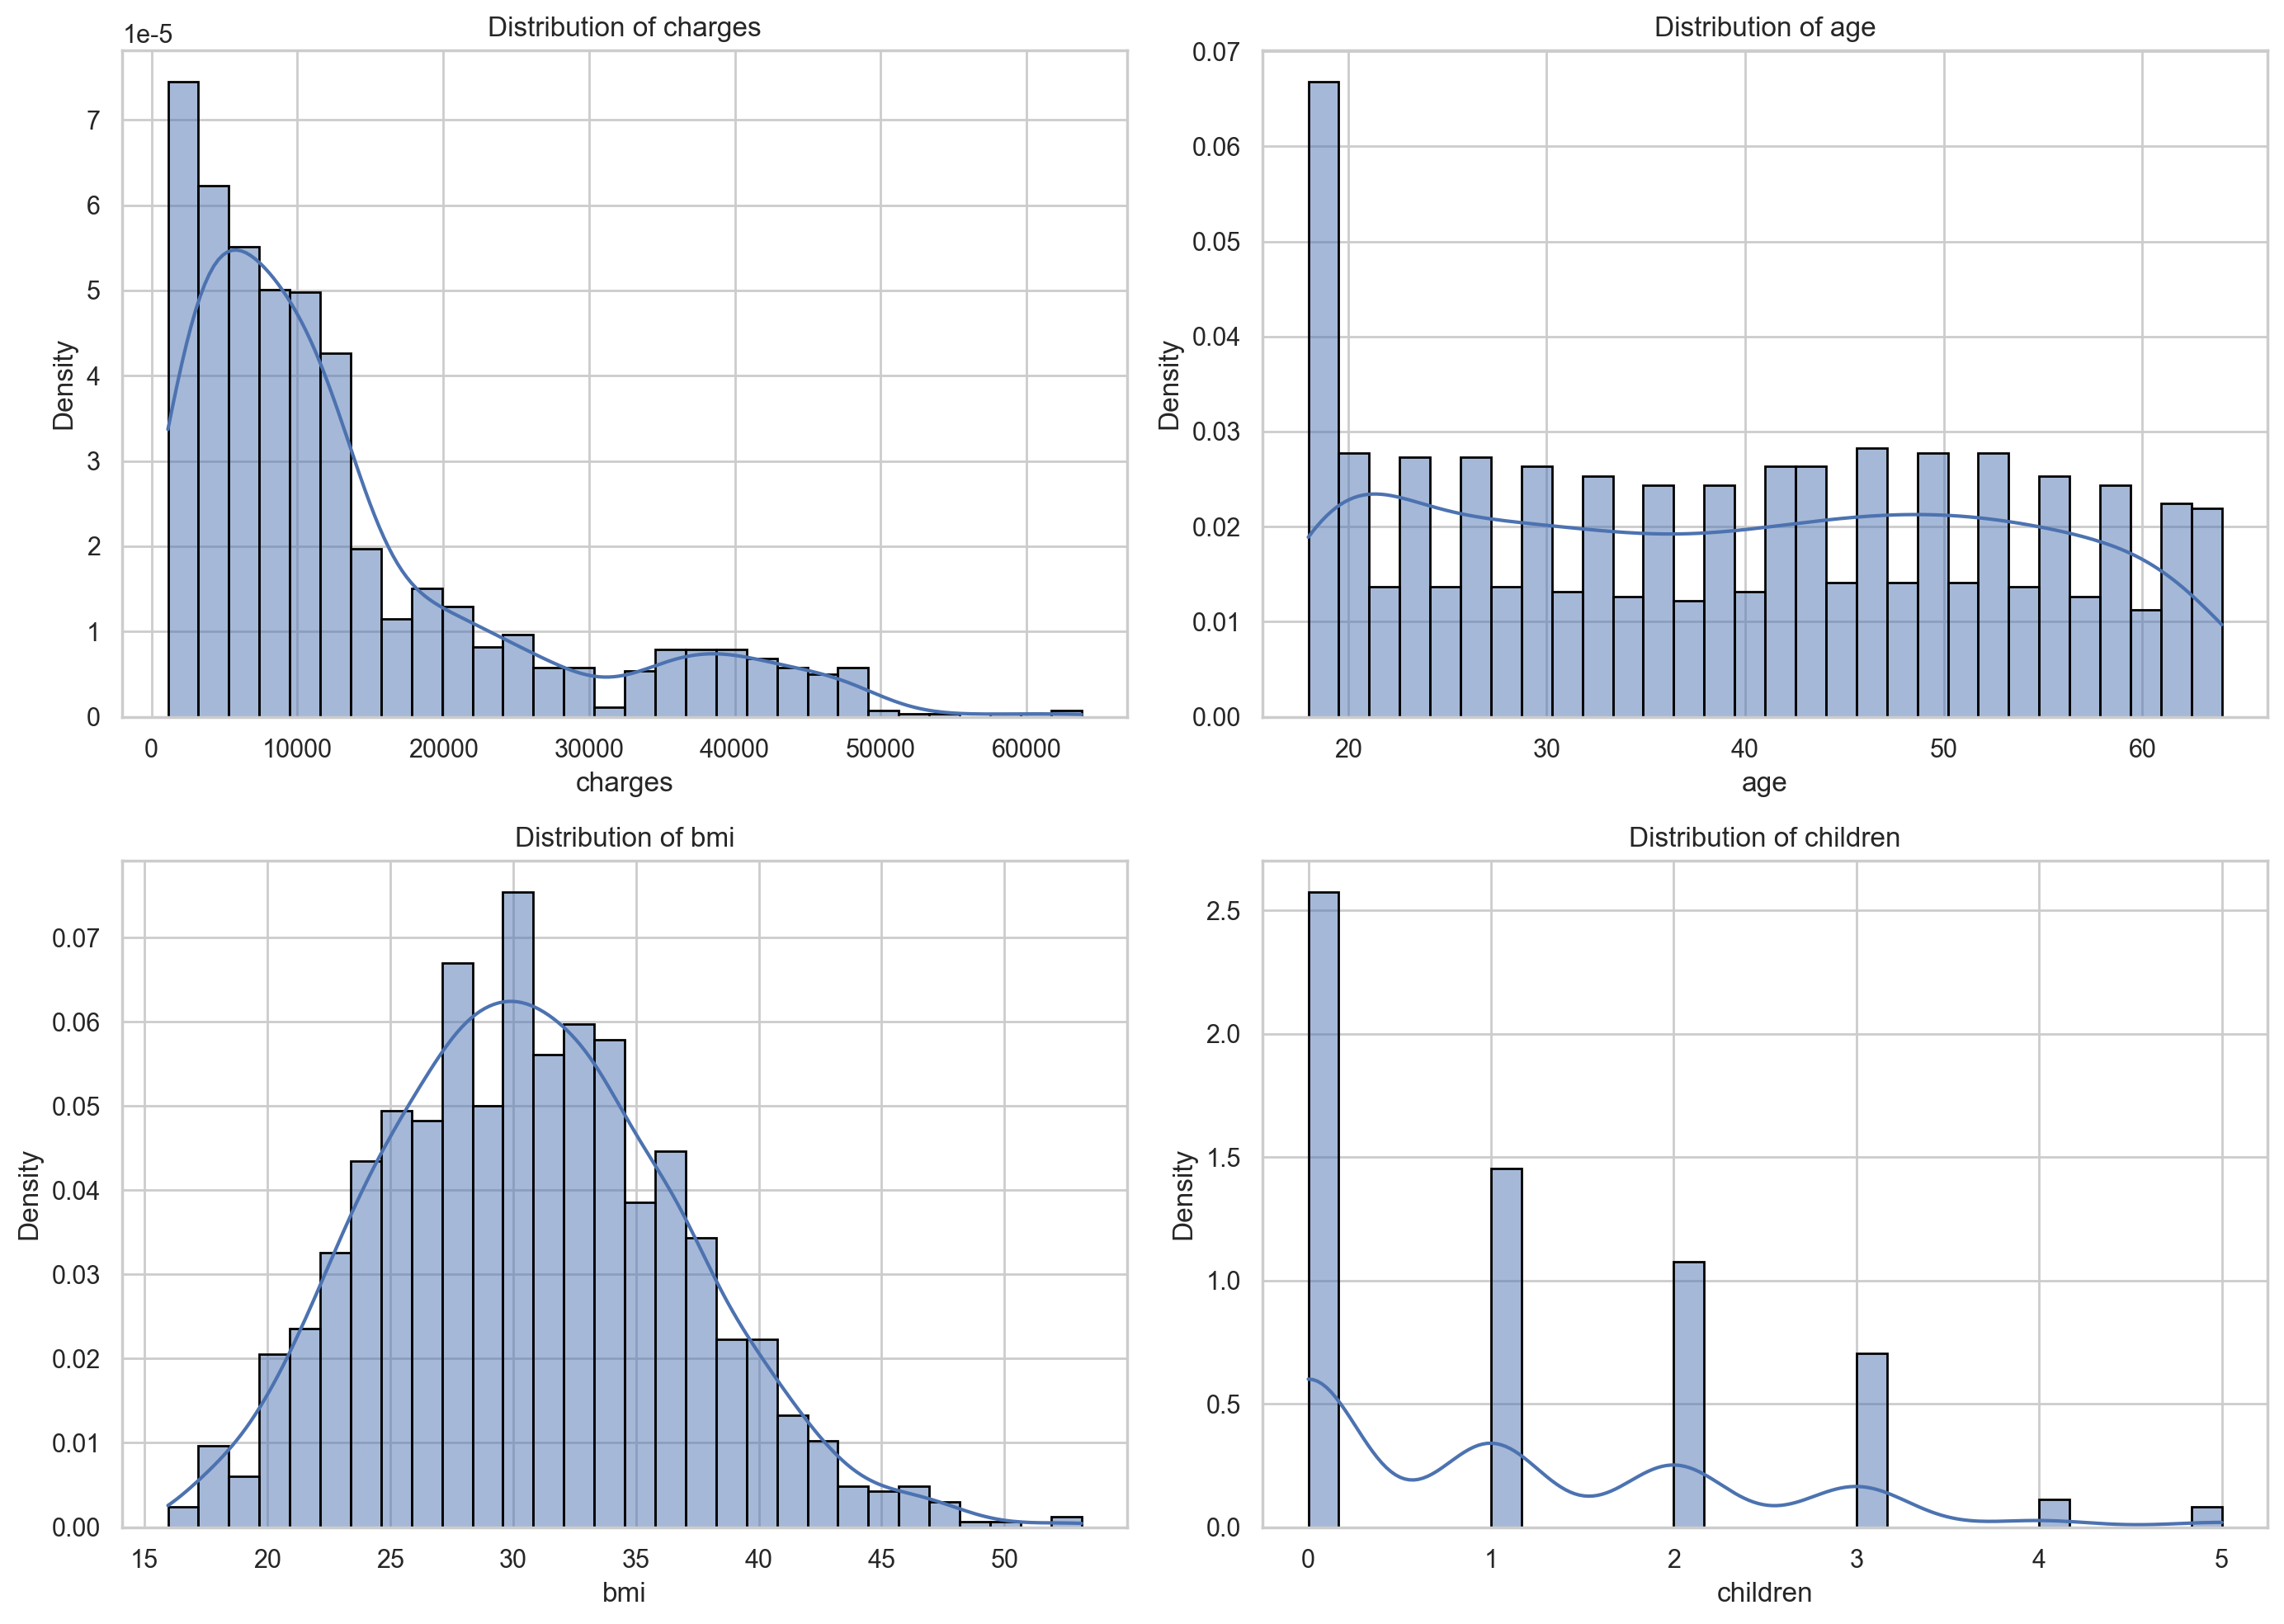

charges
강한 우측 편향
소수의 고액 청구가 평균을 크게 끌어올림


age
비교적 균등 분포


bmi
완만한 우측 편향
고BMI 구간에서 의료비 증가와 연결 가능
경계값 기반 이상치 점검은 필요
children
이산형
0~2에 집중

chilrdrens의 표본 수는  charges 값에 영향을 줄까? 


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 스타일
sns.set(style="whitegrid")

cols = ['charges', 'age', 'bmi', 'children']

plt.figure(figsize=(14, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(
        data=origin,
        x=col,
        bins=30,
        kde=True,
        stat='density',
        edgecolor='black'
    )
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()
print(f"charges\n강한 우측 편향\n소수의 고액 청구가 평균을 크게 끌어올림")
print(f"\n\nage\n비교적 균등 분포")
print(f"\n\nbmi\n완만한 우측 편향\n고BMI 구간에서 의료비 증가와 연결 가능\n경계값 기반 이상치 점검은 필요")
print(f"children\n이산형\n0~2에 집중\n")
print(f"chilrdrens의 표본 수는  charges 값에 영향을 줄까? ")

### 로그 변환

### 📝미션 3. “로그/비선형 변환을 고민해 보자”<br>charges 혹은 주요 변수(age, bmi, children)에 로그/제곱근 등 변환을 적용해 전후 분포를 나란히 비교한다.<br>변환이 해석과 모델 적합에 주는 장단점, 해석이 어떻게 달라지는지 예상한다.<br>“이 변환이 없으면 어떤 함정에 빠질까?”를 한 줄로 정리한다.<br>선택 기준을 명시하세요: 왜 log(charges)인지, 왜 특정 변수에 변환을 적용하는지 데이터 분포 근거로 설명합니다.<br>필요한 경우 Box-Cox 등의 변환을 비교해 가장 해석 친화적인 옵션을 선택하세요

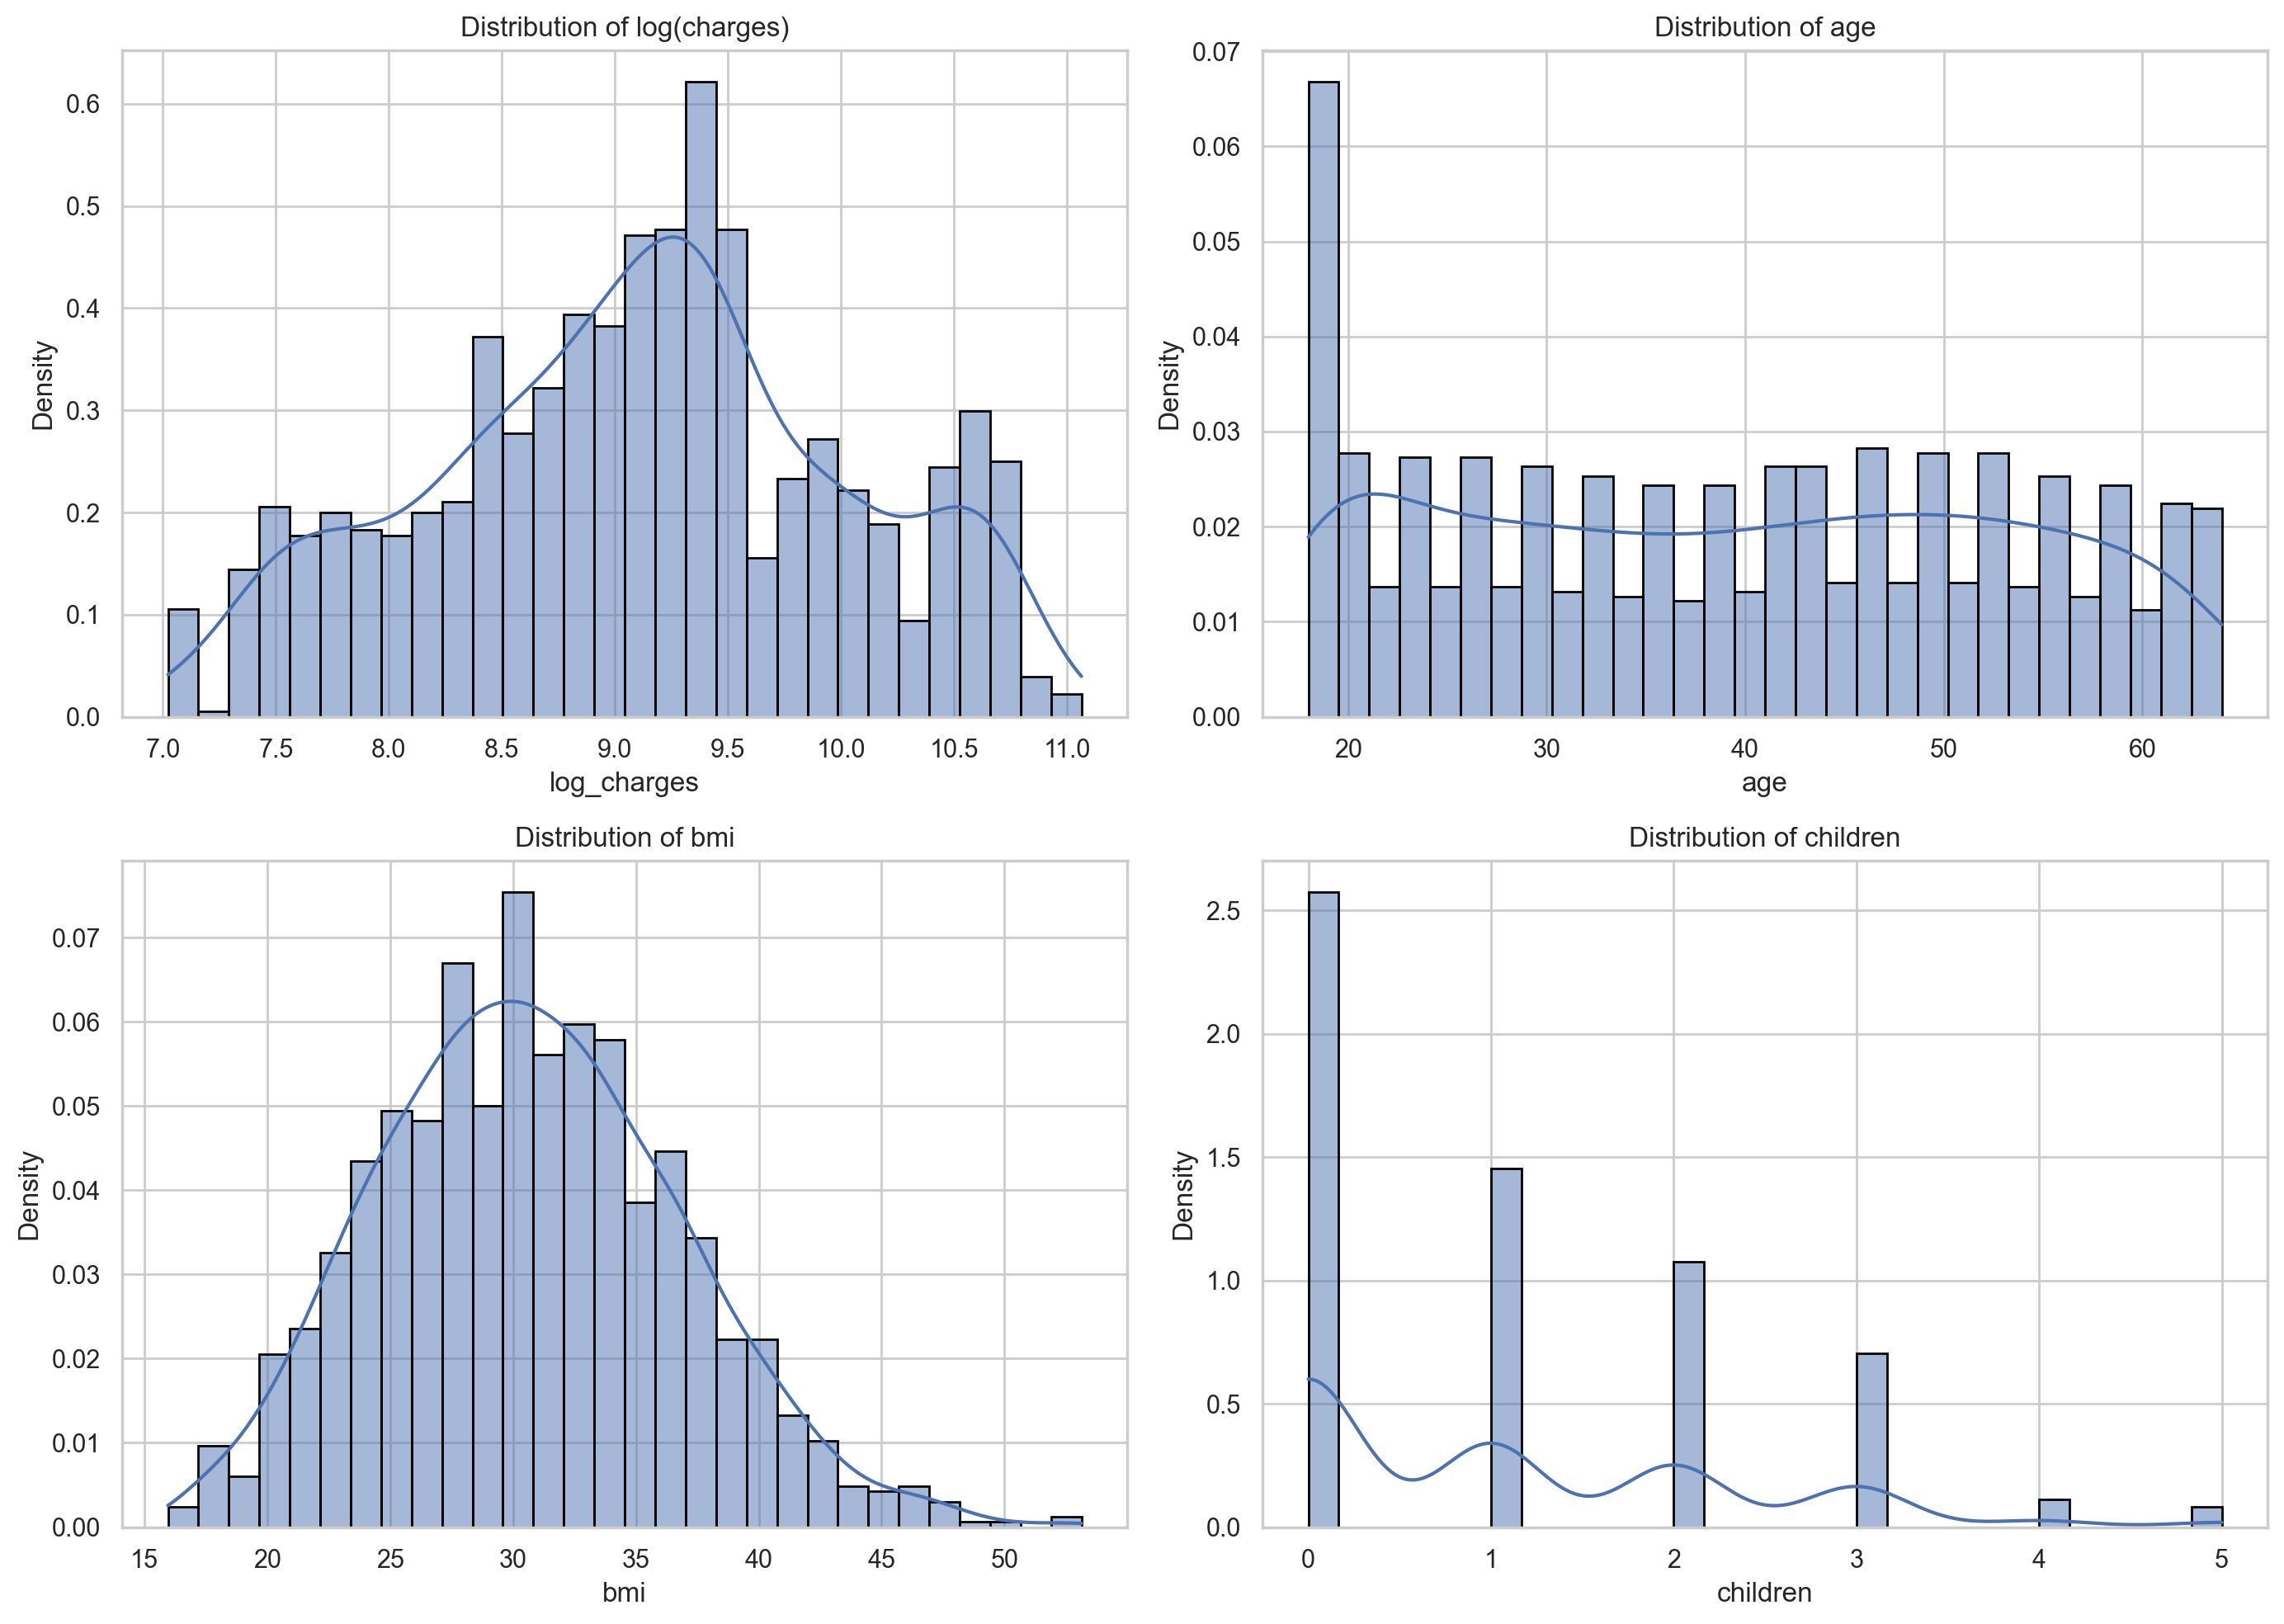

In [35]:
import numpy as np

# log 변환 (0 방지용 보정은 필요 없음: charges > 0)
origin['log_charges'] = np.log(origin['charges'])

import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 스타일
sns.set(style="whitegrid")

cols = ['log_charges', 'age', 'bmi', 'children']
titles = [
    'Distribution of log(charges)',
    'Distribution of age',
    'Distribution of bmi',
    'Distribution of children'
]

plt.figure(figsize=(14, 10))

for i, (col, title) in enumerate(zip(cols, titles), 1):
    plt.subplot(2, 2, i)
    sns.histplot(
        data=origin,
        x=col,
        bins=30,
        kde=True,
        stat='density',
        edgecolor='black'
    )
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()


대부분의 사람: 비교적 낮은 의료비

일부 소수: 매우 큰 의료비 (중증 질환, 고령, 흡연 등)

이 구조는 다음 문제를 만듭니다.

원본 분포의 문제점

평균이 대표값이 아님

극단값이 평균을 끌어올림

분산이 너무 큼

모델이 고비용 사례에 과도하게 끌려감

**선형 모델** 가정 위반

오차의 정규성 / 등분산성 깨짐

→ 그래서 **로그 변환(log transform)**을 적용함

bmi
정규성을 띄지만 우측으로 강한 꼬리




### 1️⃣ age 구간화 (18–30 / 31–50 / 51+)

In [38]:
import pandas as pd

# 연령 구간 생성
age_bins = [18, 30, 50, origin['age'].max()]
age_labels = ['18-30', '31-50', '51+']

origin['age_group'] = pd.cut(
    origin['age'],
    bins=age_bins,
    labels=age_labels,
    right=True,
    include_lowest=True
)


### 2️⃣ 연령대별 charges 분포 시각화 (Boxplot + KDE 보조)

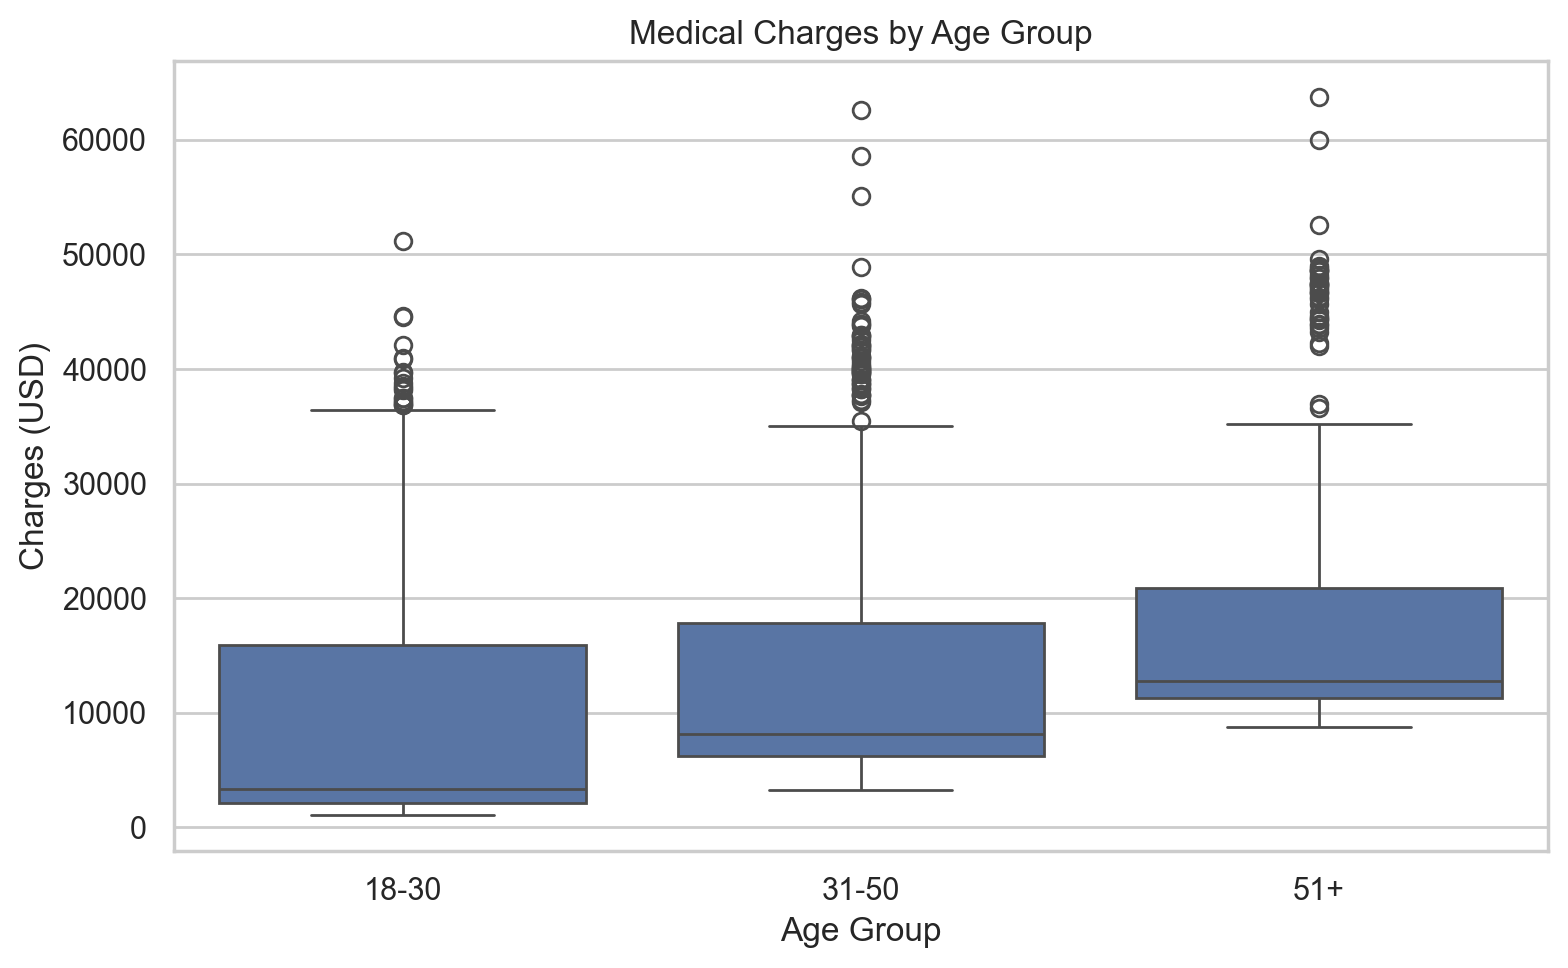

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=origin,
    x='age_group',
    y='charges'
)

plt.title('Medical Charges by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Charges (USD)')
plt.tight_layout()
plt.show()


### 3️⃣ ANOVA (일원분산분석) — log(charges) 기준

In [41]:
import numpy as np
from scipy.stats import f_oneway

# log 변환
origin['log_charges'] = np.log(origin['charges'])

# 그룹별 데이터 분리
group_18_30 = origin.loc[origin['age_group'] == '18-30', 'log_charges']
group_31_50 = origin.loc[origin['age_group'] == '31-50', 'log_charges']
group_51 = origin.loc[origin['age_group'] == '51+', 'log_charges']

# ANOVA
anova_result = f_oneway(group_18_30, group_31_50, group_51)

print("ANOVA 결과")
print(f"F-statistic: {anova_result.statistic:.4f}")
print(f"p-value: {anova_result.pvalue:.6f}")


ANOVA 결과
F-statistic: 212.0420
p-value: 0.000000


In [42]:
def log(title, width=60, char="="):
    print(f"\n{title.center(width, char)}")
log("흡연 여부에 따른 인구수 비율 차이")
def step_log(step, desc, width=60):
    title = f"[STEP {step}] {desc}"
    print(f"\n{title.center(width, '=')}")
step_log(1, "데이터 분포 확인")
step_log(2, "이상치 및 편향 여부 검증")
def warn_log(msg, width=60):
    print(f"\n{'!'*width}")
    print(msg)
    print(f"{'!'*width}")
warn_log("smoker 비율이 40% 이상 → 표본 편향 가능성 있음")
def eda_section(title, purpose, assumption=None, width=70):
    print(f"\n{title.center(width, '=')}")
    print(f"[분석 목적] {purpose}")
    if assumption:
        print(f"[사전 가설] {assumption}")
eda_section(
    title="흡연 여부 변수 분포 분석",
    purpose="데이터 내 smoker 비율이 일반 인구 분포와 유사한지 검증",
    assumption="일반 인구 대비 smoker 비율은 약 20% 내외일 것이다"
)

s_count = origin['smoker'].value_counts(normalize=True)
s_count




====================흡연 여부에 따른 인구수 비율 차이=====================

=====================[STEP 1] 데이터 분포 확인=====================

==================[STEP 2] 이상치 및 편향 여부 검증===================

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
smoker 비율이 40% 이상 → 표본 편향 가능성 있음
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

============================흡연 여부 변수 분포 분석============================
[분석 목적] 데이터 내 smoker 비율이 일반 인구 분포와 유사한지 검증
[사전 가설] 일반 인구 대비 smoker 비율은 약 20% 내외일 것이다


smoker
no     0.795217
yes    0.204783
Name: proportion, dtype: float64

### 1️⃣ 분석 대상 연속형 변수 선택

In [43]:
import pandas as pd

num_cols = ['age', 'bmi', 'children', 'charges']
data_num = origin[num_cols]


### 2️⃣ 상관행렬 계산 (Pearson)

In [45]:
corr_matrix = data_num.corr(method='pearson')
corr_matrix


,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


### 3️⃣ 상관행렬 히트맵 시각화

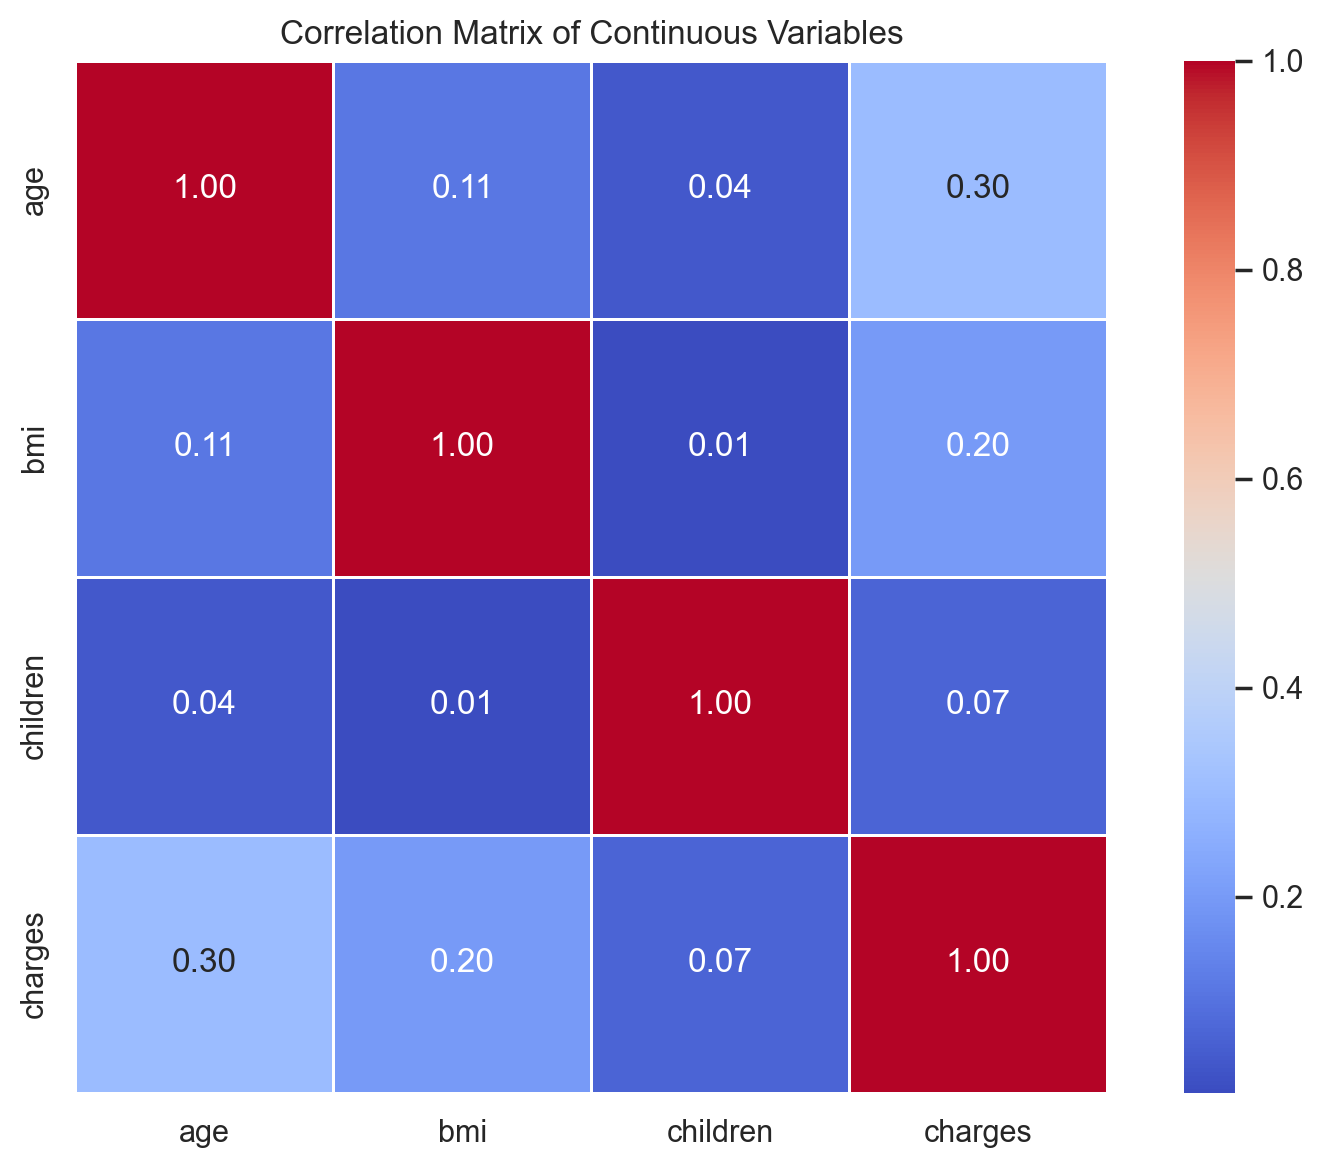

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix of Continuous Variables")
plt.tight_layout()
plt.show()


EDA결론 템플릿

In [33]:
def eda_conclusion(summary, risk=None):
    print("\n[분석 결론]")
    print(f"- {summary}")
    if risk:
        print(f"[주의 사항] {risk}")

# 사용 예시 다시 작성
eda_conclusion(
    summary="smoker 비율이 약 20%로 일반 인구 분포와 유사함",
    risk="표본 수가 적은 경우 지역 편향 가능성은 추가 검토 필요"
)




[분석 결론]
- smoker 비율이 약 20%로 일반 인구 분포와 유사함
[주의 사항] 표본 수가 적은 경우 지역 편향 가능성은 추가 검토 필요


In [34]:
eda_section(
    title="흡연 여부에 따른 인구수 비율 차이",
    purpose="smoker 변수의 표본 편향 여부 점검",
    assumption="일반적으로 smoker 비율은 20% 내외"
)

s_count = origin['smoker'].value_counts(normalize=True)
s_count

if s_count.get("yes", 0) >= 0.4:
    warn_log("smoker 비율 40% 이상 → 표본 편향 강하게 의심됨")
else:
    print("\n[INFO] smoker 비율 정상 범위")



=========================흡연 여부에 따른 인구수 비율 차이==========================
[분석 목적] smoker 변수의 표본 편향 여부 점검
[사전 가설] 일반적으로 smoker 비율은 20% 내외

[INFO] smoker 비율 정상 범위


In [14]:
# BMI 구간 정의 (의학적으로 합리적인 기준)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# BMI 구간화
bmi_bins = [0, 18.5, 25, 30, 35, 100]
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese I', 'Obese II+']

origin['bmi_group'] = pd.cut(
    origin['bmi'],
    bins=bmi_bins,
    labels=bmi_labels
)


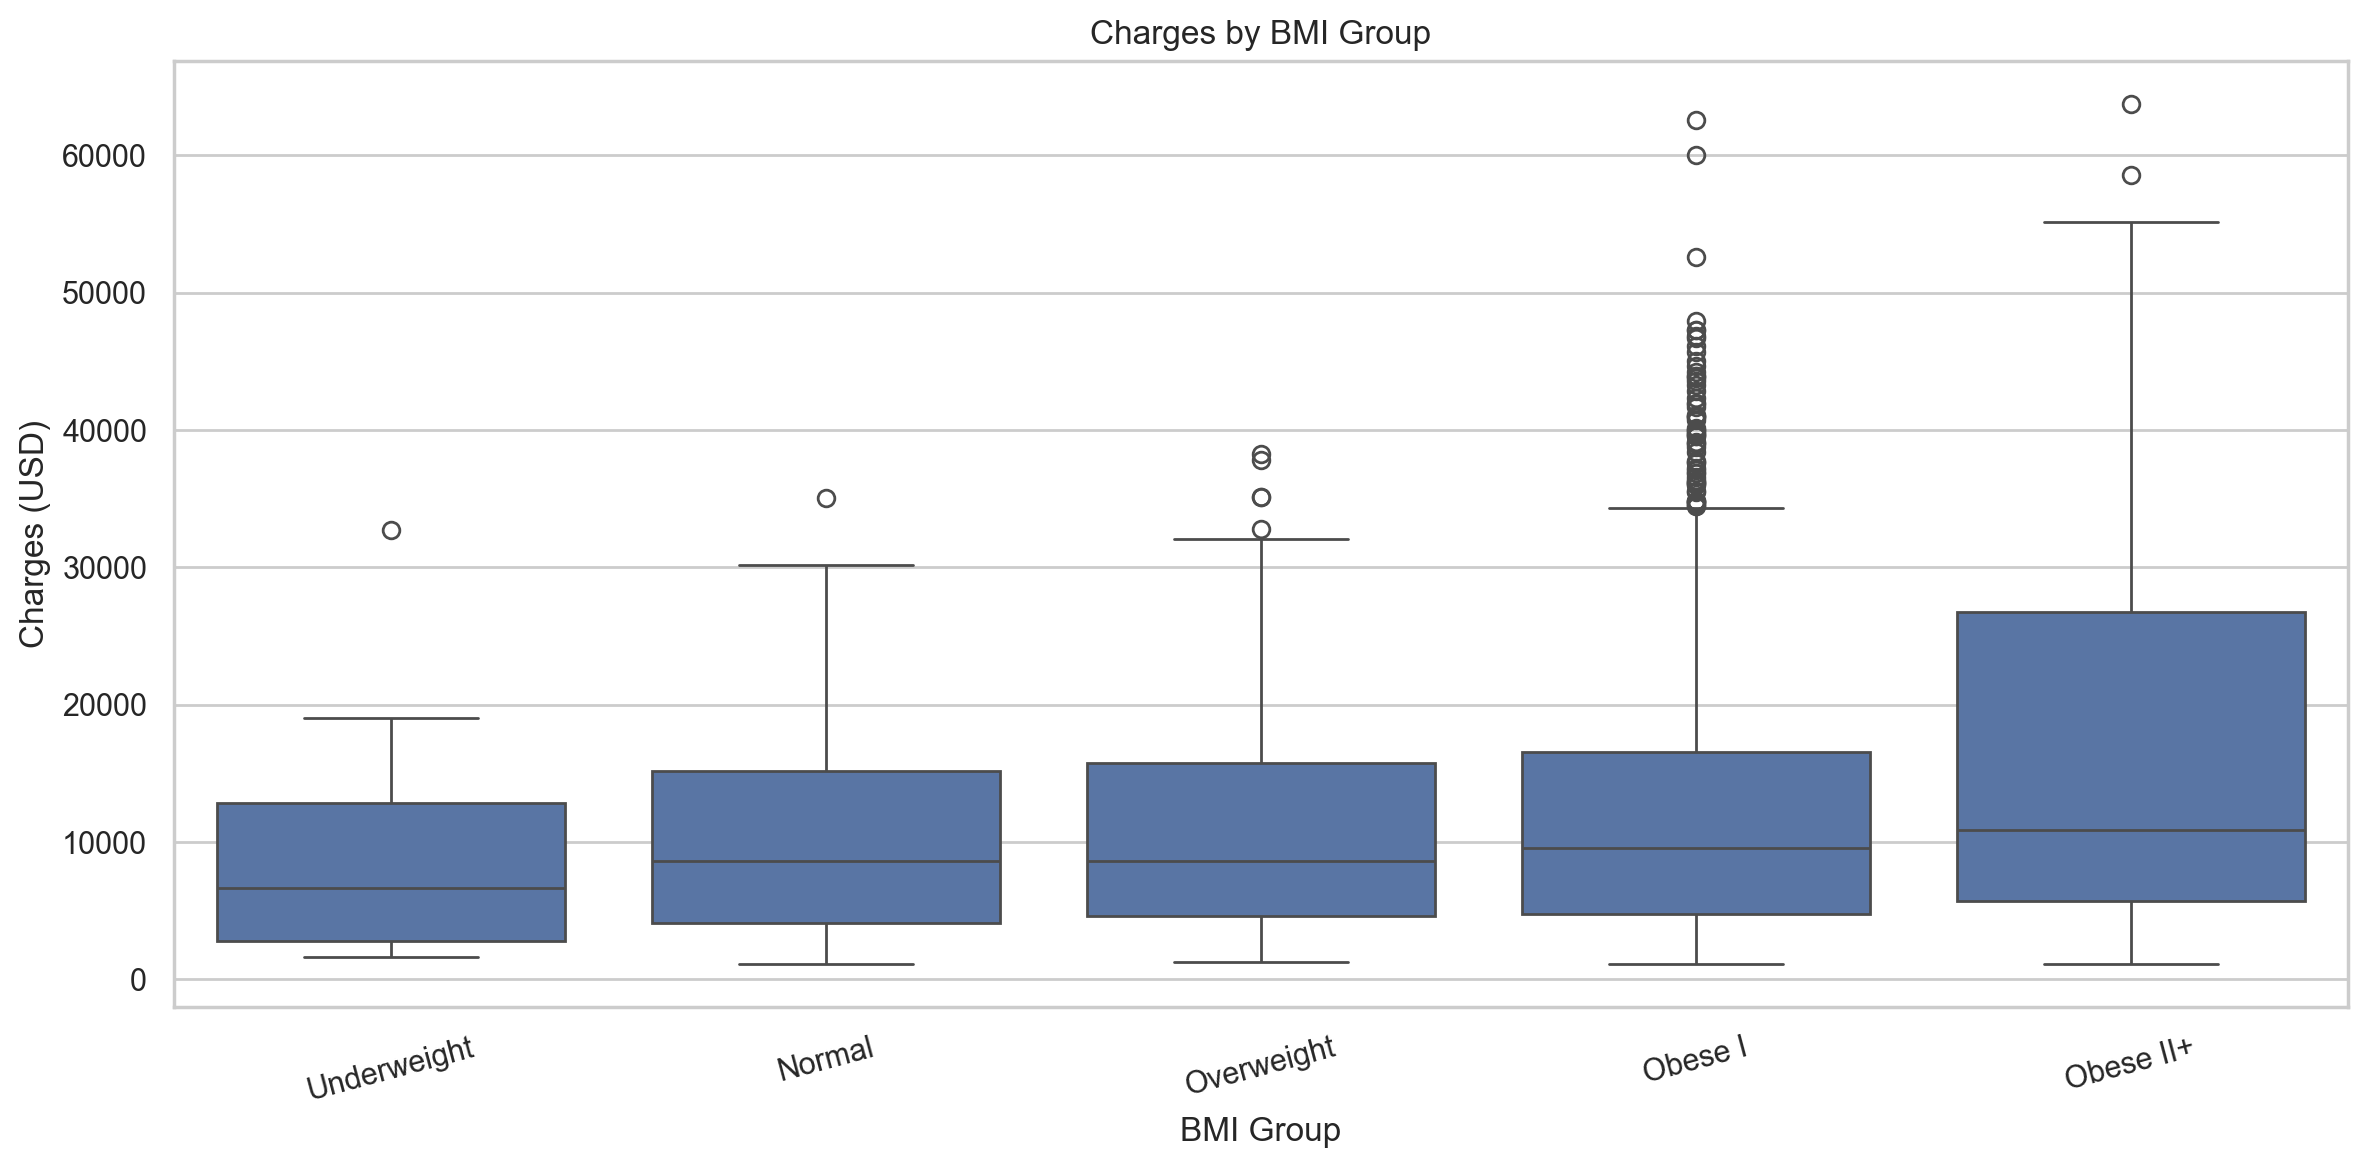

In [15]:
# BMI 구간별 charges Boxplot
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=origin,
    x='bmi_group',
    y='charges'
)

plt.title('Charges by BMI Group')
plt.xlabel('BMI Group')
plt.ylabel('Charges (USD)')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


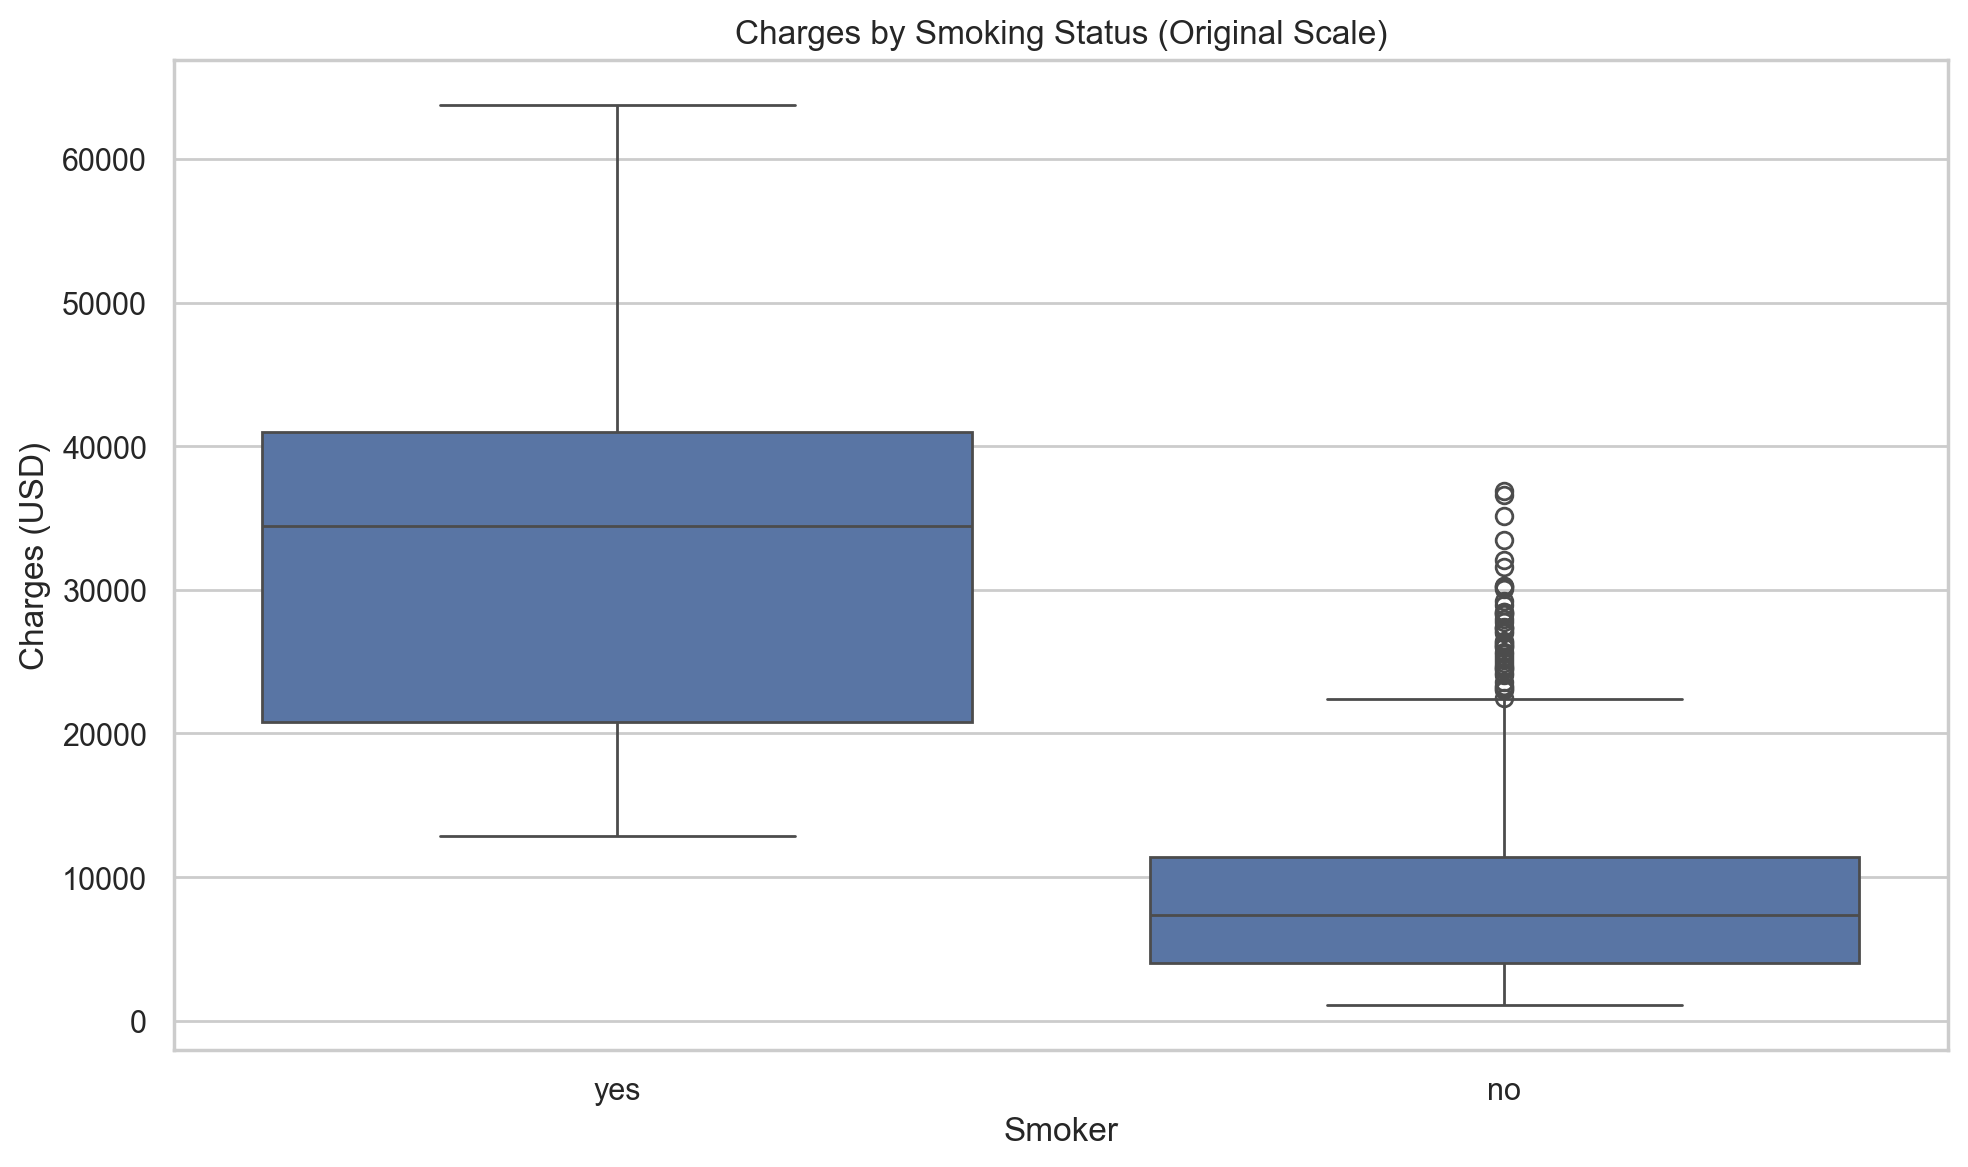

In [16]:
# 흡연자 vs 비흡연자 차이
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=origin,
    x='smoker',
    y='charges'
)

plt.title('Charges by Smoking Status (Original Scale)')
plt.xlabel('Smoker')
plt.ylabel('Charges (USD)')

plt.tight_layout()
plt.show()


In [17]:
# smoker = yes 데이터
yes_charges = origin.loc[origin['smoker'] == 'yes', 'charges']

Q1_yes = yes_charges.quantile(0.25)
Q3_yes = yes_charges.quantile(0.75)

print(f"[smoker = yes]")
print(f"25% (Q1): {Q1_yes:,.2f}")
print(f"75% (Q3): {Q3_yes:,.2f}")
print(f"IQR 범위: {Q1_yes:,.2f} ~ {Q3_yes:,.2f}")


[smoker = yes]
25% (Q1): 20,826.24
75% (Q3): 41,019.21
IQR 범위: 20,826.24 ~ 41,019.21


In [18]:
# smoker = no 데이터
no_charges = origin.loc[origin['smoker'] == 'no', 'charges']

Q1_no = no_charges.quantile(0.25)
Q3_no = no_charges.quantile(0.75)
IQR_no = Q3_no - Q1_no

lower_bound = Q1_no - 1.5 * IQR_no
upper_bound = Q3_no + 1.5 * IQR_no

# 이상치 판별
outliers_no = no_charges[
    (no_charges < lower_bound) | (no_charges > upper_bound)
]

outlier_ratio = len(outliers_no) / len(no_charges) * 100

print(f"[smoker = no]")
print(f"이상치 개수: {len(outliers_no)}")
print(f"전체 관측치 수: {len(no_charges)}")
print(f"이상치 비율: {outlier_ratio:.2f}%")


[smoker = no]
이상치 개수: 46
전체 관측치 수: 1064
이상치 비율: 4.32%


In [19]:
origin.groupby('smoker')['charges'].describe()


,count,mean,std,min,25%,50%,75%,max
smoker,,,,,,,,
no,1064.0,8434.268298,5993.781819,1121.8739,3986.438700,7345.40530,11362.887050,36910.60803
yes,274.0,32050.231832,11541.547176,12829.4551,20826.244213,34456.34845,41019.207275,63770.42801


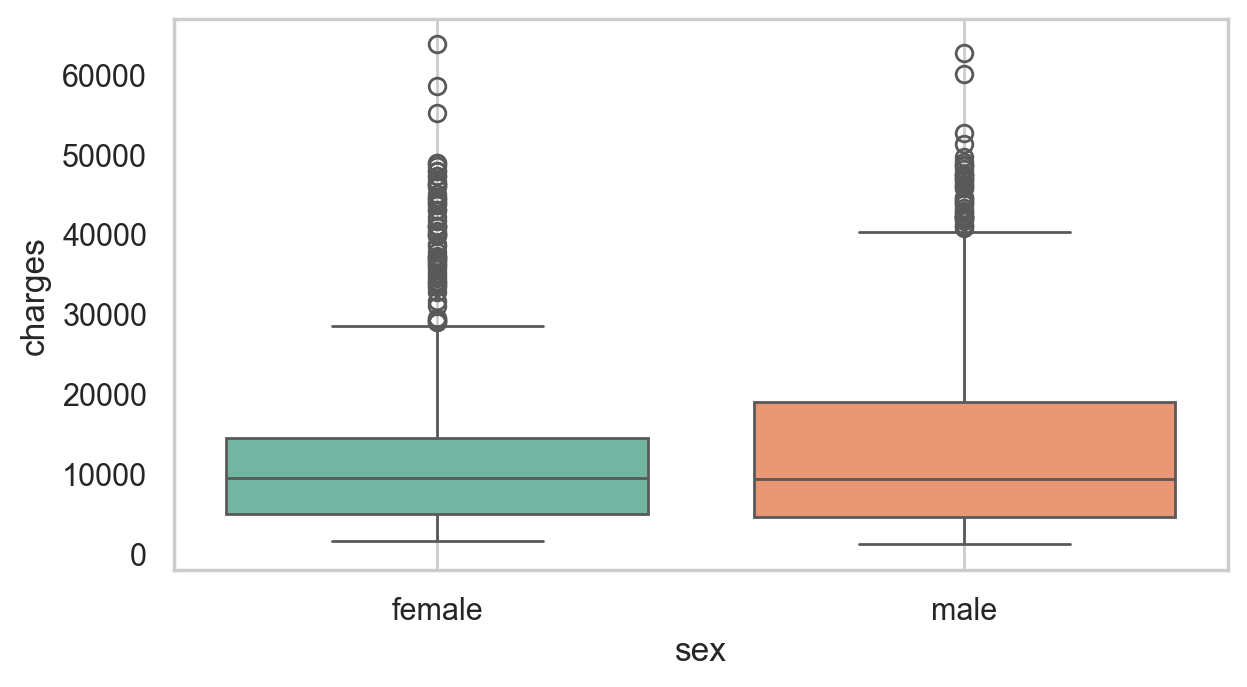

In [20]:
# 박스플롯
hs_plot.hs_boxplot(df = origin, xname="sex", yname="charges", palette = "Set2",  hue="sex")


In [21]:
origin.groupby('sex')['charges'].describe()

,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
female,662.0,12569.578844,11128.703801,1607.5101,4885.1587,9412.96250,14454.691825,63770.42801
male,676.0,13956.751178,12971.025915,1121.8739,4619.1340,9369.61575,18989.590250,62592.87309


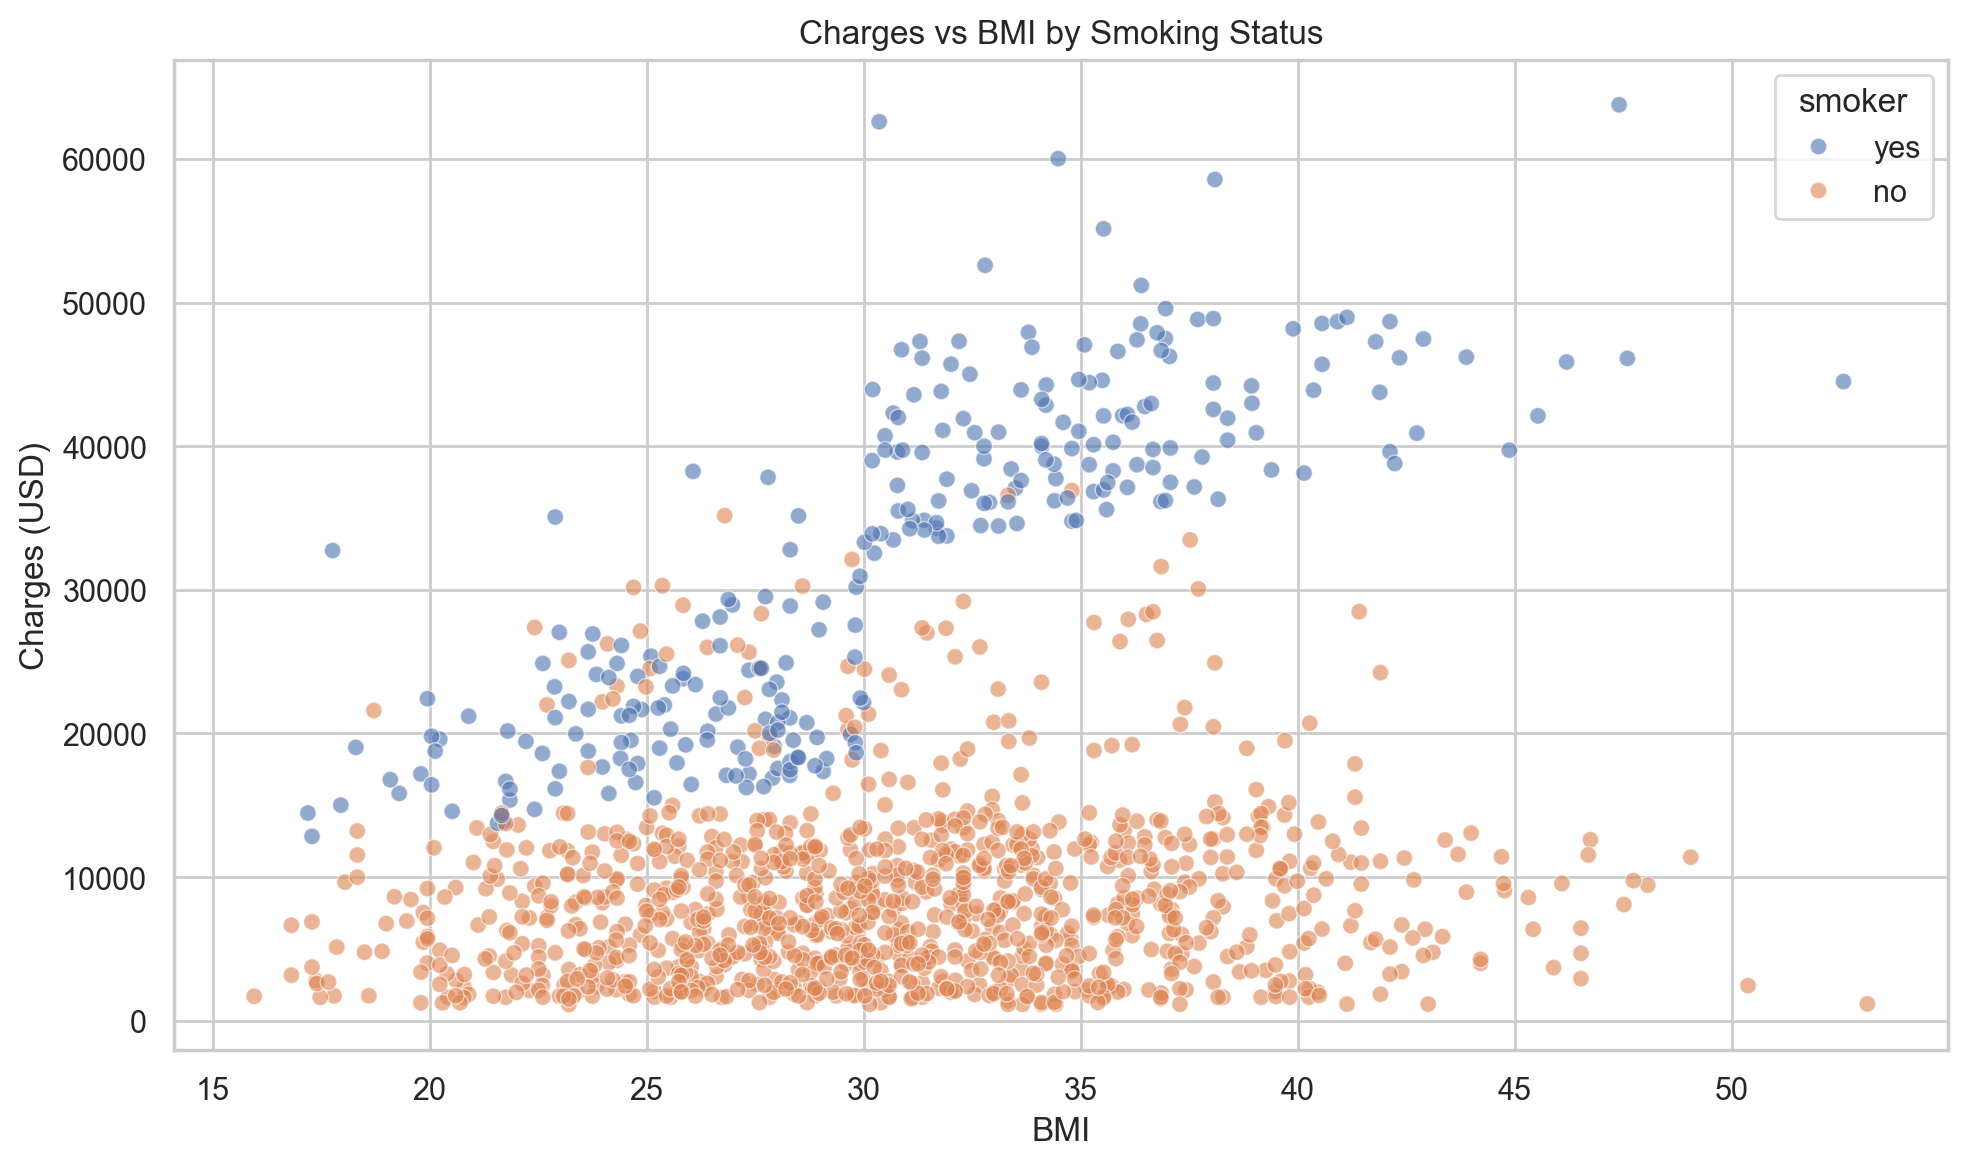

In [22]:
# BMI vs charges, 흡연 여부로 분리
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=origin,
    x='bmi',
    y='charges',
    hue='smoker',
    alpha=0.6
)

plt.title('Charges vs BMI by Smoking Status')
plt.xlabel('BMI')
plt.ylabel('Charges (USD)')
plt.tight_layout()
plt.show()


📝미션 4. “성별과 거주 지역은 의료비를 결정할까?”성별(sex)과 지역(region)별 의료비 분포를 시각화(박스플롯, 바이올린 플롯)한다.중앙값·분포 겹침을 근거로 “어느 집단이 비싼가?”, “차이가 얼마나 뚜렷한가?”를 문장으로 적으세요.• • • • • • • • • • • • • • • • 
“왜 이런 차이가 생겼을까?”를 건강보험 체계·지역 의료 인프라·생활 비용 차이 등으로 추정해 보세요

📝미션 5. “흡연은 정말로 의료비를 크게 높일까?”smoker(흡연 여부)에 따라 charges가 다른지 시각화하고, 두 집단 평균 차이를 가설검정(예: t-test)으로 확인한다.효과 크기(차이의 크기)를 함께 제시하고, “실제로 의미 있는 차이인가?”를 말로 해석하세요.정규성/등분산 가정 점검 후 필요 시 Welch’s t-test나 비모수 검정을 선택하세요.효과 크기는 Cohen's d 또는 Hedges' g로 제시하고, 의료 정책 관점에서 의미를 한 줄로 번역합니다

📝미션 6. “나이대별로 의료비 차이가 뚜렷할까?”age를 여러 구간으로 나누어(예: 18~30, 31~50, 51+) 각 연령대별 charges 분포를 시각화한다.분산분석(ANOVA)으로 전체 차이를 확인하고, 사후검정으로 어느 연령대 사이에서 차이가 나는지 정리한다.사후검정은 Tukey HSD 또는 Games-Howell(등분산 위반 시)을 사용하고, “의료비 연령 서열표” 형태로 요약하세요

📝미션 7. “변수들은 서로 섞여 있을까?”주요 연속형 변수 간 상관행렬(age, bmi, children, charges)을 계산한다.상관행렬을 히트맵으로 시각화하고, Variance Inflation Factor(VIF)로 다중공선성을 점검한다.age와 bmi 같이 약한 상관을 보이는 변수들이 모델에 주는 정보를 논의하세요.공선성 문제가 없다면 그 이유를, 있다면 완화 전략(변수 제거, 결합지표, 정규화 회귀)을 비교하세요

📝미션 8. “어떤 변수가 의료비와 가장 가까울까?”charges와 age, bmi, children의 상관을 계산한다.Pearson과 Spearman을 모두 계산하고, 비교해 무엇이 더 적합한지 이유를 적으세요.각 변수의 관계를 의료학·보건학적 언어로 해석하고(예: “나이가 많을수록 의료비 증가”, “과체중(높은 BMI)은 의료비와 강한 관계”), 인과성을 말할 수 있는지 비판적으로 평가합니다

📝미션 9. “상관관계는 곧 원인일까?”지금까지의 탐색 결과를 바탕으로 “상관이 높다 = 원인이다”라는 착각을 피하자.예: age와 charges의 높은 상관이 정말 나이 자체가 비용을 결정하는가, 아니면 나이가 건강 상태의 대리변수인가?smoker 효과: 흡연자는 정말 더 많이 병에 걸려서인가, 아니면 보험사의 위험 평가 기준인가?데이터 수집 시점·의료 접근성 차이·미측정 변수(직업, 교육, 소득)가 결론에 주는 한계를 서술하세요

📝미션 10. “의료비를 설명하는 회귀모형 설계”charges(또는 변환값)를 종속변수로 하는 다중선형회귀를 설계한다.변수 선택·인코딩(범주형 처리)·스케일/변환 이유를 “설명하고 싶어서” 관점으로 글로 남긴다.학습/검증 데이터 분리 방식(예: train/test split 80/20)을 명시한다.검증 전략을 구체화하세요: train/test split에 더해 K-fold(예: 5-fold)로 평균 성능과 분산을 함께 보고합니다.과적합·공선성 위험 완화를 위해 Ridge/Lasso/Elastic Net을 후보로 비교하고, “해석-성능” 균형 관점에서 선택이유를 기록합니다.

📝미션 11. “회귀계수는 무엇을 말해주나?”계수(또는 표준화 계수)와 신뢰구간, 방향·크기를 해석한다.“나이가 1년 늘면 의료비가 어떻게 변하는가”, “흡연자는 비흡연자보다 평균 얼마나 더 높은 비용을 지불하는가” 처럼 물리/의료적 의미로 번역한다.변환 변수가 있다면, 변환을 감안한 해석을 명확히 쓴다.표준화 계수(베타)와 비표준화 계수를 병행 제시하고, 단위/변환을 고려한 해석 문장을 명확히 작성합니다.범주형 변수(sex, smoker, region)의 계수는 기준 범주 대비 효과로 명확히 해석하세요

📝미션 12. “모형 진단과 개선”잔차 정규성/등분산/선형성, 영향력을 잔차플롯, Q-Q, Cook’s distance 등으로 점검한다.문제 지점(예: 극단적 고액 청구, 특정 집단에서의 체계적 오류)과 개선 아이디어(변환, 변수 교체/제거, 강건 회귀등)를 제안한다.R², RMSE/MAE 등 기본 지표를 보고하고, 실제 의료비 예측에서 이 오차가 얼마나 의미 있는지 해석하세요.캘리브레이션(예측 vs. 실제) 산점도를 함께 제시하고, 체계적 과소/과대 예측 구간을 언급하세요.K-fold 평균 지표와 표준편차를 보고하여 안정성을 함께 판단합니다

📝미션 13. “같은 나이인데 왜 의료비는 다를까?”age가 같은 두 가상의 개인을 설정하고(예: A는 비흡연 저BMI, B는 흡연 고BMI), 다른 변수 차이로 의료비 차이를설명한다.비전공자에게 이야기하듯, 모델이 설명하는 것과 못하는 것을 구분해 제시한다.이야기의 흐름을 “데이터 관찰 → 회귀계수 → 의료비 차이 설명” 순서로 연결한다.예시 틀: “두 사람 모두 40세이지만, A는 흡연하지 않고 BMI가 25인 반면 B는 흡연자이고 BMI가 35입니다. 모델에따르면 B의 예상 의료비는 A보다 훨씬 높습니다. 왜냐하면 흡연이 [계수] 만큼 비용을 증가시키고, BMI 1 증가가[계수] 만큼 증가시키기 때문입니다. 하지만 이 모델은 개인의 건강 이력, 유전 요인, 직업 스트레스 같은 정보를 담지 못합니다.”모델이 설명하지 못한 요인(개인 건강 이력, 유전 요인, 사회경제적 지위, 의료 접근성 등)의 가능성도 덧붙여 설득력을 높입니다.